# AI vs. Human Children's Video Features — Extended Statistical Analysis

This notebook picks up from the cleaned dataset (`cleaned_dataset.csv`) and goes deeper:
distribution diagnostics, the loudness mean-vs-median discrepancy, full per-feature
diagnostics, robust test selection, effect sizes with bootstrap confidence intervals,
and correlation structure within each group.

**How to use in Colab:**
1. Upload `cleaned_dataset.csv` (Files pane → upload), or mount Drive and point `DATA_PATH` at it.
2. Run cells top to bottom.


## 1. Setup

In [ ]:
!pip install -q scipy statsmodels seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'cleaned_dataset.csv'  # change if uploading elsewhere / mounting Drive
df = pd.read_csv(DATA_PATH)

FEATURES = ['shot_count_per_sec','avg_shot_duration_sec','num_cuts','duration_sec',
            'brightness_mean','saturation_mean','color_warmness_pct','visual_complexity',
            'loudness','tempo_bpm','sound_brightness']

ai_df = df[df.label == 'ai'].copy()
human_df = df[df.label == 'human'].copy()

print(f"AI: n={len(ai_df)}   Human: n={len(human_df)}")
df.head()

AI: n=290   Human: n=265


,video_id,filename,label,shot_count_per_sec,avg_shot_duration_sec,num_cuts,duration_sec,brightness_mean,saturation_mean,color_warmness_pct,visual_complexity,loudness,tempo_bpm,sound_brightness
0,6lRy1ZZQtes,6lRy1ZZQtes_A Fox Saved a Lost Duckling ❤️ ｜ E...,ai,1.2079,0.828,83,68.714,148.352,148.439,0.4190,7.698,0.4449,144.23,2057.82
1,ba62uuv-5Dc,ba62uuv-5Dc_Rollin' France - what if animals w...,ai,0.0374,26.735,5,133.674,111.368,94.276,0.3995,7.061,0.0511,112.50,4400.59
2,cxPPu15-gUw,cxPPu15-gUw_Child and dragon bond ｜ 4K AI Anim...,ai,0.0363,27.531,5,137.654,95.079,107.278,0.3751,6.947,0.0673,148.03,1047.70
3,PSGkTU9BVxU,PSGkTU9BVxU_ai cartoon animal story in Urdu ｜ ...,ai,0.1481,6.754,21,141.834,88.228,92.212,0.6845,7.151,0.0990,114.80,1983.61
4,MVkJsLh8F20,MVkJsLh8F20_✨ Magical Fairy Forest Adventure 🌳...,ai,0.4571,2.188,32,70.014,114.808,88.610,0.3538,7.548,0.0394,148.03,3322.97


## 2. Why Welch's t-test and Mann-Whitney U can disagree

Welch's t-test compares **means** and is sensitive to outliers / heavy tails via the
variance term. Mann-Whitney U compares **rank distributions** (effectively medians/location)
and is robust to outliers. When a feature is right-skewed with a handful of extreme values
in one group, those outliers can inflate that group's mean and variance enough to erase a
mean-level difference in Welch's test — while the *bulk* of the distribution has clearly
shifted, which MWU picks up.

`loudness` is exactly this case: Welch p=.195 (not significant) vs Mann-Whitney U p=.005
(significant). Let's diagnose it directly.

In [ ]:
feat = 'loudness'
a = ai_df[feat].dropna()
h = human_df[feat].dropna()

diag = pd.DataFrame({
    'AI': [a.mean(), a.median(), a.std(), stats.skew(a), stats.kurtosis(a), a.min(), a.max()],
    'Human': [h.mean(), h.median(), h.std(), stats.skew(h), stats.kurtosis(h), h.min(), h.max()],
}, index=['mean','median','sd','skew','excess_kurtosis','min','max'])
diag.round(4)

,AI,Human
mean,0.0831,0.0901
median,0.0620,0.0759
sd,0.0700,0.0543
skew,2.5130,0.9566
excess_kurtosis,7.7528,0.6797
min,0.0066,0.0044
max,0.4449,0.3235


In [ ]:
# Outlier counts via IQR fence (Tukey's rule)
def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    return (s > upper).sum(), upper

for name, s in [('AI', a), ('Human', h)]:
    n_out, fence = iqr_outliers(s)
    print(f"{name}: {n_out} values above upper fence ({fence:.4f}); max={s.max():.4f}")

AI: 21 values above upper fence (0.1855); max=0.4449
Human: 3 values above upper fence (0.2243); max=0.3235


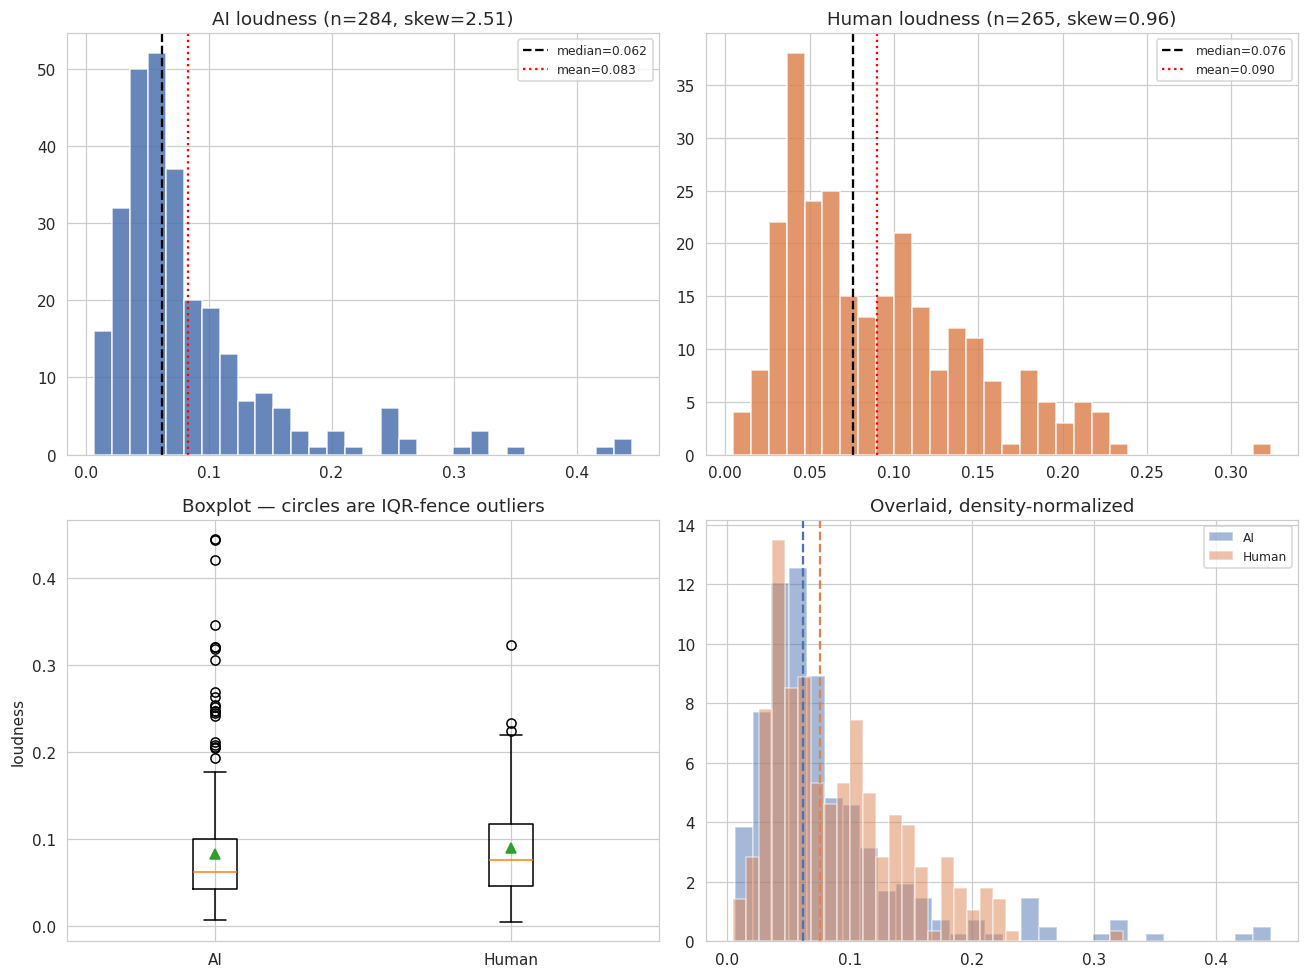

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(a, bins=30, color='#4C72B0', alpha=0.85)
axes[0,0].axvline(a.median(), color='black', linestyle='--', label=f'median={a.median():.3f}')
axes[0,0].axvline(a.mean(), color='red', linestyle=':', label=f'mean={a.mean():.3f}')
axes[0,0].set_title(f'AI {feat} (n={len(a)}, skew={stats.skew(a):.2f})')
axes[0,0].legend(fontsize=8)

axes[0,1].hist(h, bins=30, color='#DD8452', alpha=0.85)
axes[0,1].axvline(h.median(), color='black', linestyle='--', label=f'median={h.median():.3f}')
axes[0,1].axvline(h.mean(), color='red', linestyle=':', label=f'mean={h.mean():.3f}')
axes[0,1].set_title(f'Human {feat} (n={len(h)}, skew={stats.skew(h):.2f})')
axes[0,1].legend(fontsize=8)

axes[1,0].boxplot([a, h], tick_labels=['AI','Human'], showmeans=True)
axes[1,0].set_title('Boxplot — circles are IQR-fence outliers')
axes[1,0].set_ylabel(feat)

axes[1,1].hist(a, bins=30, alpha=0.5, density=True, label='AI', color='#4C72B0')
axes[1,1].hist(h, bins=30, alpha=0.5, density=True, label='Human', color='#DD8452')
axes[1,1].axvline(a.median(), color='#4C72B0', linestyle='--')
axes[1,1].axvline(h.median(), color='#DD8452', linestyle='--')
axes[1,1].set_title('Overlaid, density-normalized')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading the plot:** AI `loudness` is heavily right-skewed (skew≈2.5 vs ≈1.0 for human)
with a long tail of high-loudness outliers (~21 AI clips above the IQR fence vs ~3 for human).
That tail pulls the AI **mean** up toward the human mean, masking a real difference — but the
**bulk** of the AI distribution sits measurably lower than human (AI median ≈0.062 vs human
median ≈0.076; roughly 64% of AI clips fall below the human median vs the expected ~50%).
This is why MWU (rank-based, outlier-robust) finds significance that the mean-based Welch
test doesn't: **most AI clips are quieter than most human clips, but a minority of unusually
loud AI clips distort the group mean.** Worth flagging in a paper as a location-shift finding,
not a mean-difference finding — and worth reporting the median-based effect size (rank-biserial)
rather than Cohen's d for this specific feature.

## 3. Distribution diagnostics for every feature (not just loudness)

In [ ]:
diag_rows = []
for f in FEATURES:
    a = ai_df[f].dropna()
    h = human_df[f].dropna()
    diag_rows.append({
        'feature': f,
        'ai_skew': stats.skew(a), 'human_skew': stats.skew(h),
        'ai_kurt': stats.kurtosis(a), 'human_kurt': stats.kurtosis(h),
        'ai_outliers': iqr_outliers(a)[0], 'human_outliers': iqr_outliers(h)[0],
    })
diag_df = pd.DataFrame(diag_rows).round(3)
diag_df['flag_skewed'] = (diag_df[['ai_skew','human_skew']].abs().max(axis=1) > 1)
diag_df.sort_values('flag_skewed', ascending=False)

,feature,ai_skew,human_skew,ai_kurt,human_kurt,ai_outliers,human_outliers,flag_skewed
0,shot_count_per_sec,1.775,3.039,5.990,21.391,10,6,True
1,avg_shot_duration_sec,3.032,2.555,9.141,5.834,45,42,True
2,num_cuts,1.761,1.174,4.727,2.557,12,4,True
7,visual_complexity,-3.556,-0.861,15.405,-0.011,0,0,True
8,loudness,2.513,0.957,7.753,0.680,21,3,True
3,duration_sec,0.294,-0.357,-0.179,-1.097,0,0,False
4,brightness_mean,0.328,-0.793,1.410,-0.061,8,0,False
5,saturation_mean,0.158,-0.036,0.705,-0.234,4,0,False
6,color_warmness_pct,-0.083,0.420,-0.604,-0.081,0,3,False
9,tempo_bpm,0.832,0.509,2.265,0.718,4,9,False


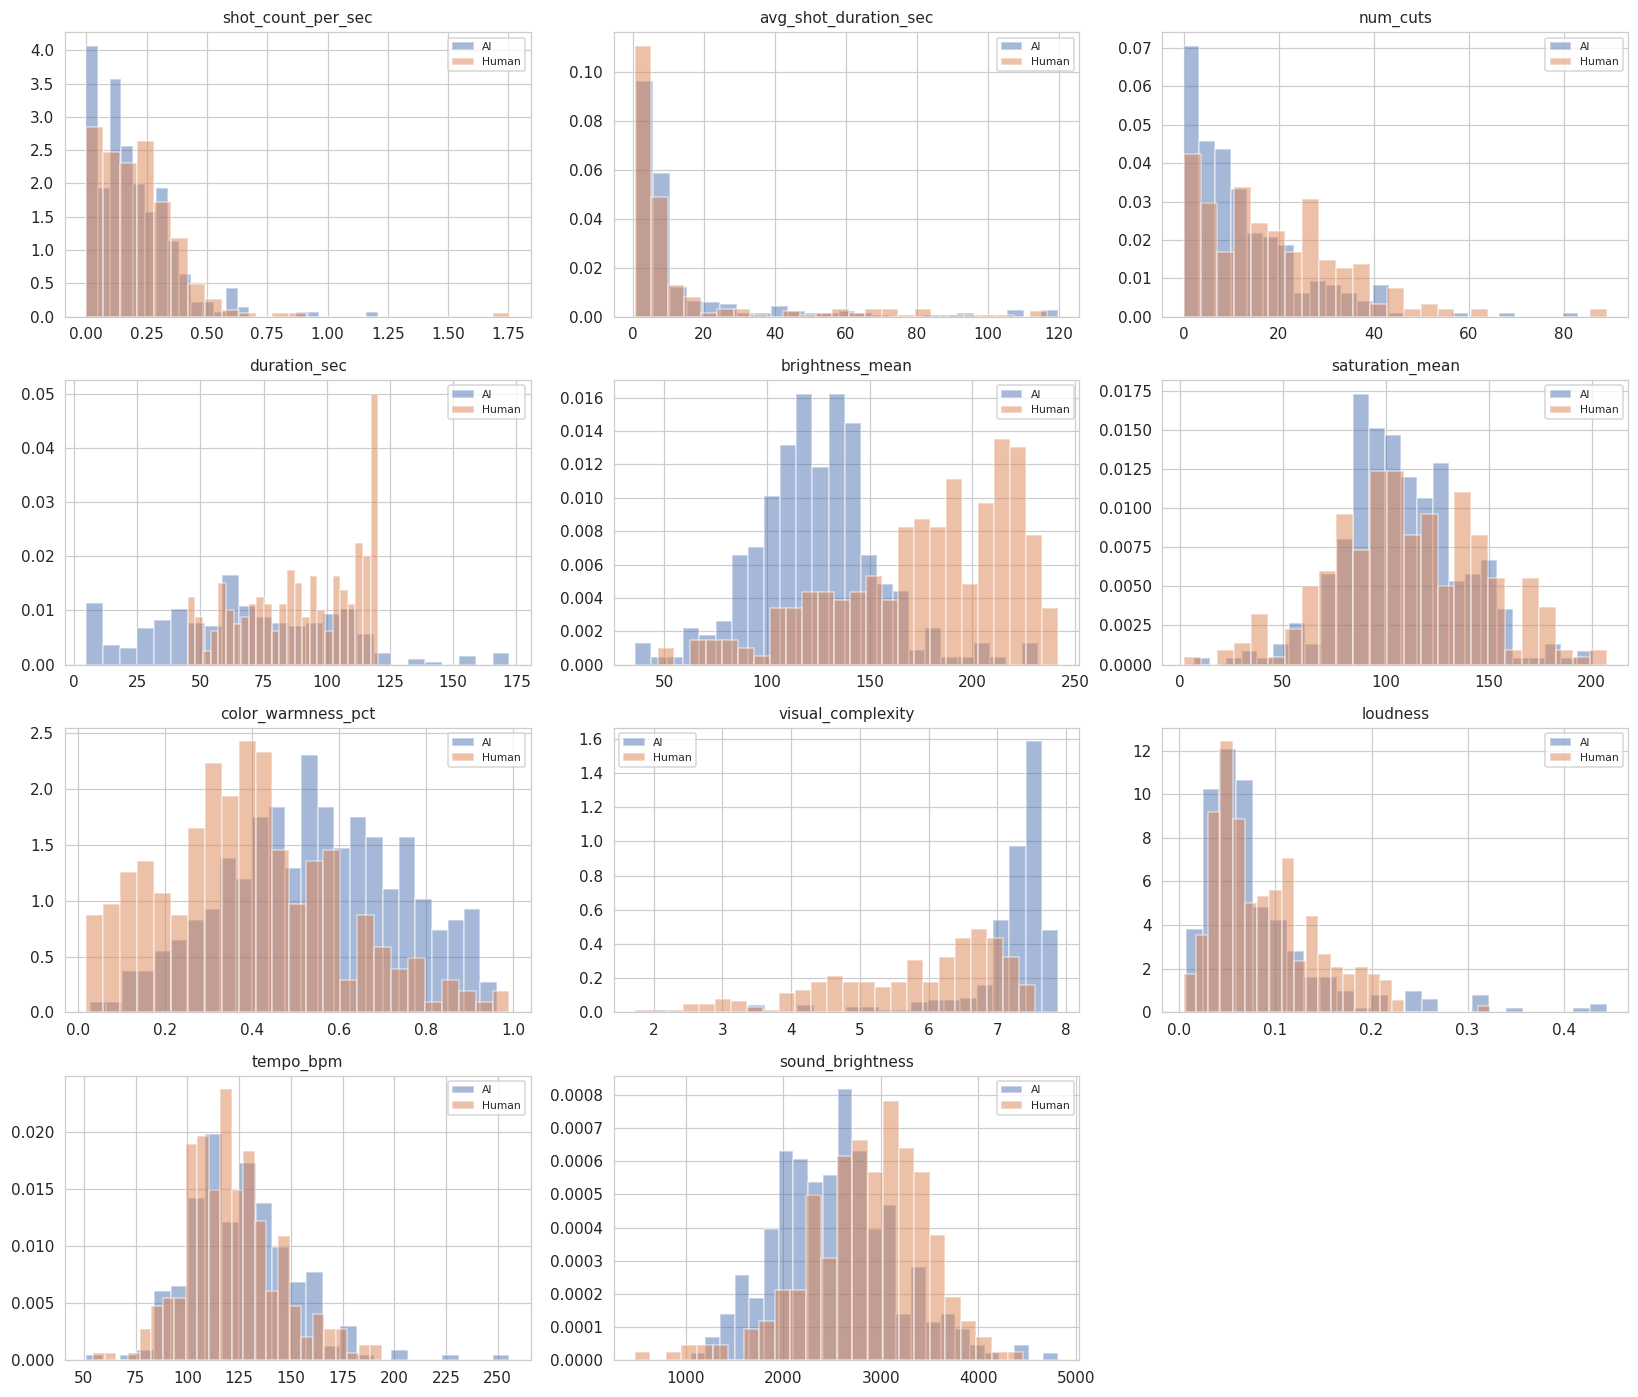

In [ ]:
# Grid of histograms for every feature, AI vs Human overlaid
n = len(FEATURES)
cols = 3
rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3.2))
axes = axes.flatten()
for i, f in enumerate(FEATURES):
    a = ai_df[f].dropna()
    h = human_df[f].dropna()
    axes[i].hist(a, bins=25, alpha=0.5, density=True, label='AI', color='#4C72B0')
    axes[i].hist(h, bins=25, alpha=0.5, density=True, label='Human', color='#DD8452')
    axes[i].set_title(f, fontsize=10)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

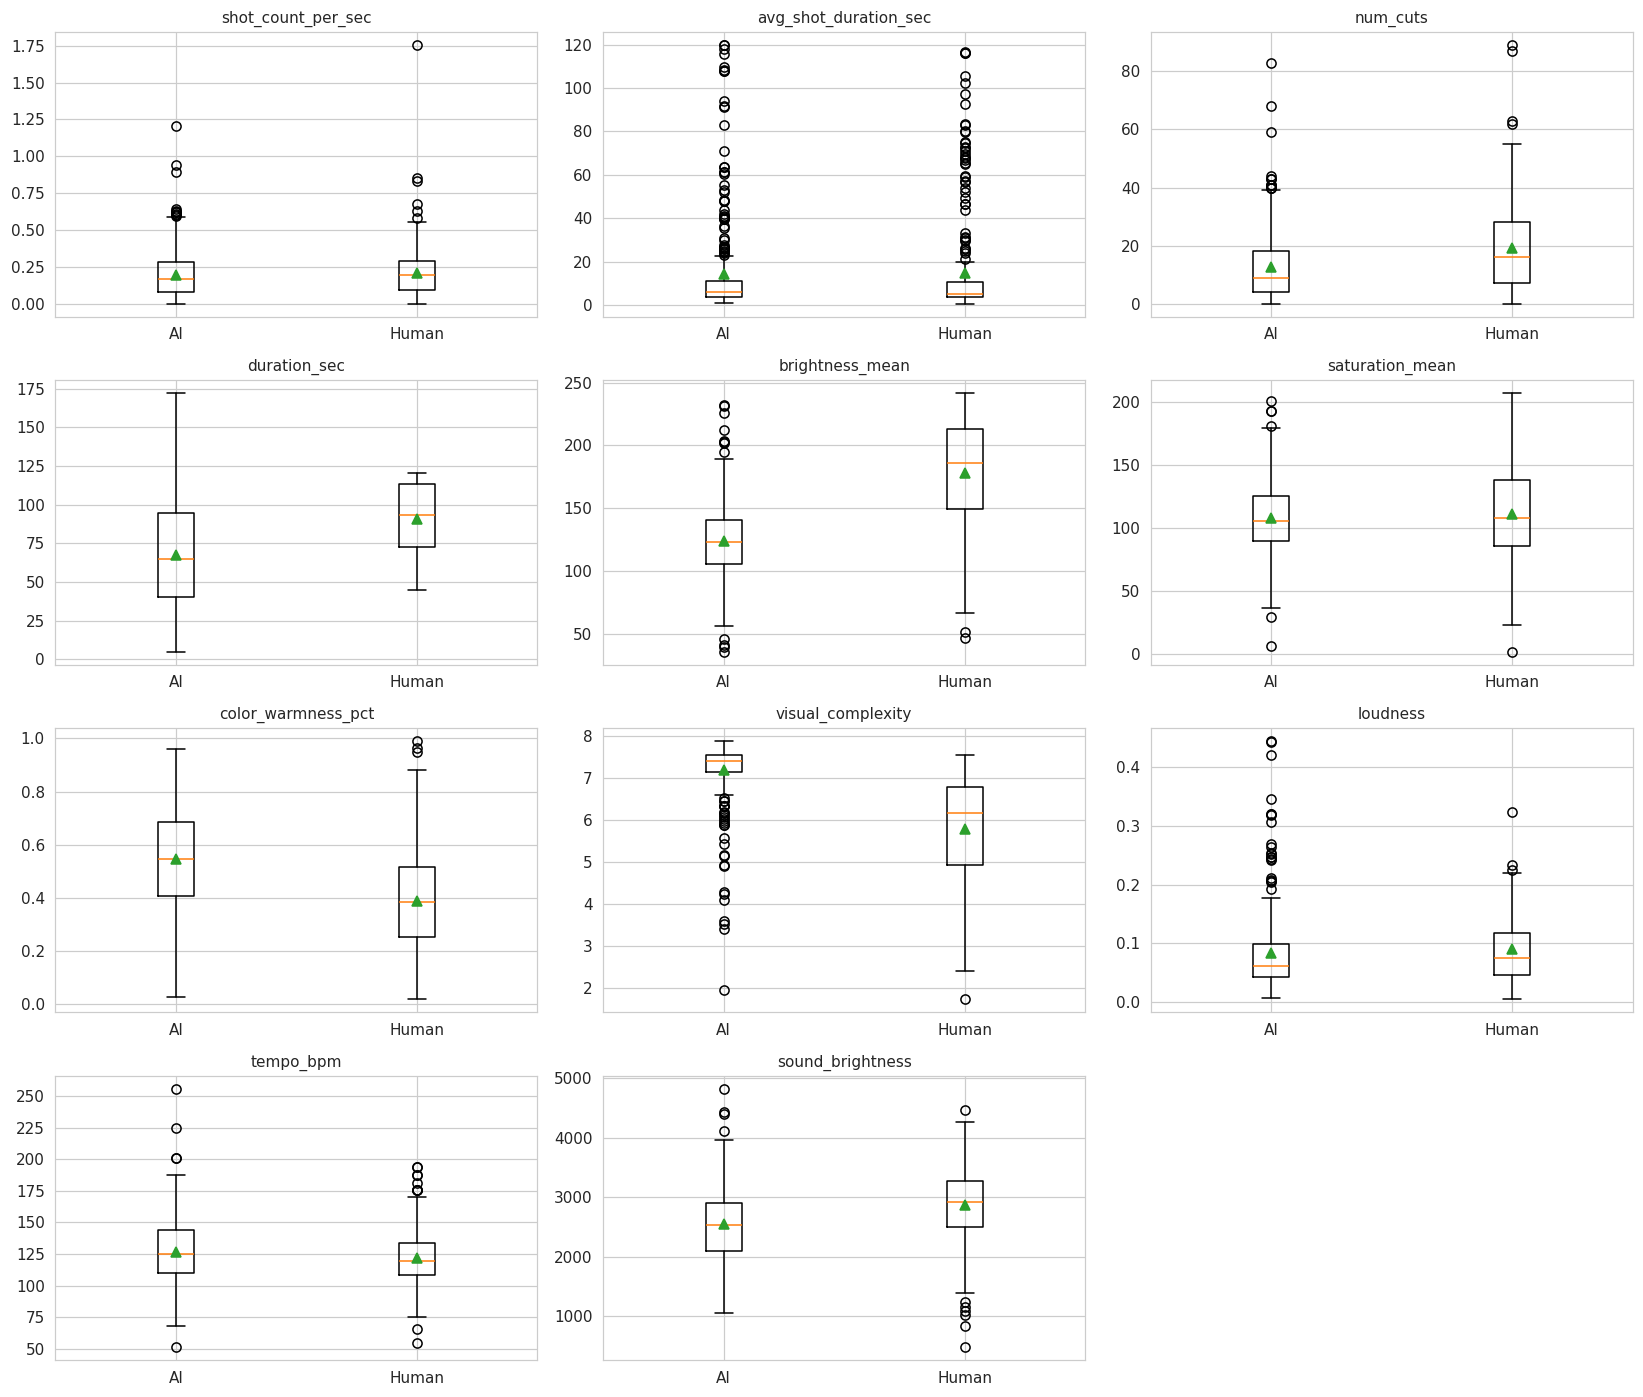

In [ ]:
# Grid of boxplots for every feature
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3.2))
axes = axes.flatten()
for i, f in enumerate(FEATURES):
    a = ai_df[f].dropna()
    h = human_df[f].dropna()
    axes[i].boxplot([a, h], tick_labels=['AI','Human'], showmeans=True)
    axes[i].set_title(f, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 4. Full test suite per feature

For each feature: Shapiro-Wilk normality (both groups), Levene's test for equal variances,
Welch's t-test + Cohen's d, Mann-Whitney U + rank-biserial correlation, and a bootstrap 95% CI
for the median difference (robust, distribution-free).

In [ ]:
def bootstrap_median_diff_ci(a, h, n_boot=5000, ci=95, seed=1):
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        h_s = rng.choice(h, size=len(h), replace=True)
        diffs[i] = np.median(a_s) - np.median(h_s)
    lo, hi = np.percentile(diffs, [(100-ci)/2, 100-(100-ci)/2])
    return lo, hi

results = []
for f in FEATURES:
    a = ai_df[f].dropna().values
    h = human_df[f].dropna().values

    sh_a = stats.shapiro(a if len(a) <= 5000 else np.random.choice(a, 5000, replace=False))[1]
    sh_h = stats.shapiro(h if len(h) <= 5000 else np.random.choice(h, 5000, replace=False))[1]
    levene_p = stats.levene(a, h)[1]

    t_stat, t_p = stats.ttest_ind(a, h, equal_var=False)
    pooled_sd = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(h)-1)*h.std(ddof=1)**2) / (len(a)+len(h)-2))
    cohens_d = (a.mean() - h.mean()) / pooled_sd

    u_stat, u_p = stats.mannwhitneyu(a, h, alternative='two-sided')
    rank_biserial = 1 - (2*u_stat) / (len(a)*len(h))

    md_lo, md_hi = bootstrap_median_diff_ci(a, h)

    results.append({
        'feature': f,
        'shapiro_ai_p': sh_a, 'shapiro_human_p': sh_h,
        'both_normal': (sh_a > 0.05) and (sh_h > 0.05),
        'levene_p': levene_p, 'equal_var': levene_p > 0.05,
        'welch_p': t_p, 'cohens_d': cohens_d,
        'mwu_p': u_p, 'rank_biserial': rank_biserial,
        'median_diff': np.median(a) - np.median(h),
        'median_diff_ci_lo': md_lo, 'median_diff_ci_hi': md_hi,
        'recommended_test': 'Mann-Whitney U' if not ((sh_a>0.05) and (sh_h>0.05)) else "Welch's t",
    })

results_df = pd.DataFrame(results).round(4)
results_df

,feature,shapiro_ai_p,shapiro_human_p,both_normal,levene_p,equal_var,welch_p,cohens_d,mwu_p,rank_biserial,median_diff,median_diff_ci_lo,median_diff_ci_hi,recommended_test
0,shot_count_per_sec,0.0000,0.0000,False,0.8978,True,0.2088,-0.1072,0.0819,0.0854,-0.0295,-0.0679,0.0083,Mann-Whitney U
1,avg_shot_duration_sec,0.0000,0.0000,False,0.7139,True,0.8506,-0.0160,0.2440,-0.0572,0.8540,-0.4240,2.1216,Mann-Whitney U
2,num_cuts,0.0000,0.0000,False,0.0010,False,0.0000,-0.4810,0.0000,0.2855,-7.0000,-10.0000,-5.0000,Mann-Whitney U
3,duration_sec,0.0002,0.0000,False,0.0000,False,0.0000,-0.7780,0.0000,0.4325,-28.2135,-33.6537,-20.0010,Mann-Whitney U
4,brightness_mean,0.0002,0.0000,False,0.0000,False,0.0000,-1.4592,0.0000,0.6788,-63.1995,-71.2851,-54.8977,Mann-Whitney U
5,saturation_mean,0.0227,0.5699,False,0.0000,False,0.3317,-0.0835,0.3391,0.0470,-2.2550,-11.1710,4.5998,Mann-Whitney U
6,color_warmness_pct,0.0554,0.0011,False,0.7079,True,0.0000,0.7817,0.0000,-0.4268,0.1634,0.1325,0.2078,Mann-Whitney U
7,visual_complexity,0.0000,0.0000,False,0.0000,False,0.0000,1.3782,0.0000,-0.7998,1.2385,1.0540,1.5225,Mann-Whitney U
8,loudness,0.0000,0.0000,False,0.8290,True,0.1947,-0.1099,0.0047,0.1395,-0.0139,-0.0272,-0.0034,Mann-Whitney U
9,tempo_bpm,0.0000,0.0003,False,0.0646,True,0.0254,0.1907,0.0422,-0.1002,5.3200,0.0000,8.1600,Mann-Whitney U


**How to read `recommended_test`:** if either group fails Shapiro-Wilk (p<.05, i.e. not
normal), Mann-Whitney U is the more defensible primary test — most features here will land in
that bucket, consistent with the earlier finding that none of the 11 features were normally
distributed in both groups.

## 5. Effect size forest plot

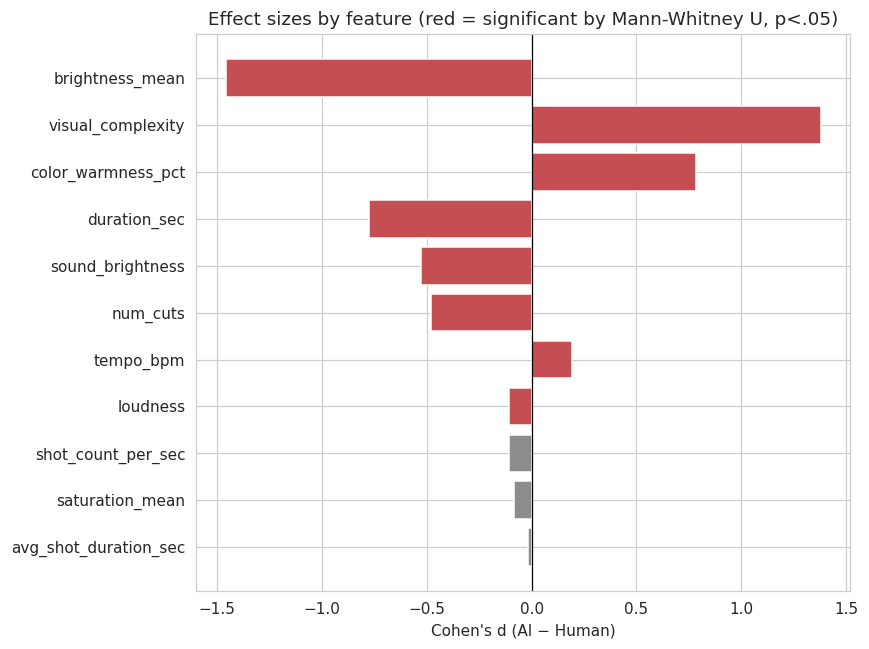

In [ ]:
plot_df = results_df.copy().sort_values('cohens_d', key=lambda s: s.abs(), ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if p < 0.05 else '#8C8C8C' for p in plot_df['mwu_p']]
ax.barh(plot_df['feature'], plot_df['cohens_d'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Cohen's d (AI − Human)")
ax.set_title('Effect sizes by feature (red = significant by Mann-Whitney U, p<.05)')
plt.tight_layout()
plt.show()

## 6. Correlation structure within each group

Useful for checking whether features are redundant (e.g. does `num_cuts` just track
`duration_sec`?) before treating them as independent evidence in write-up.

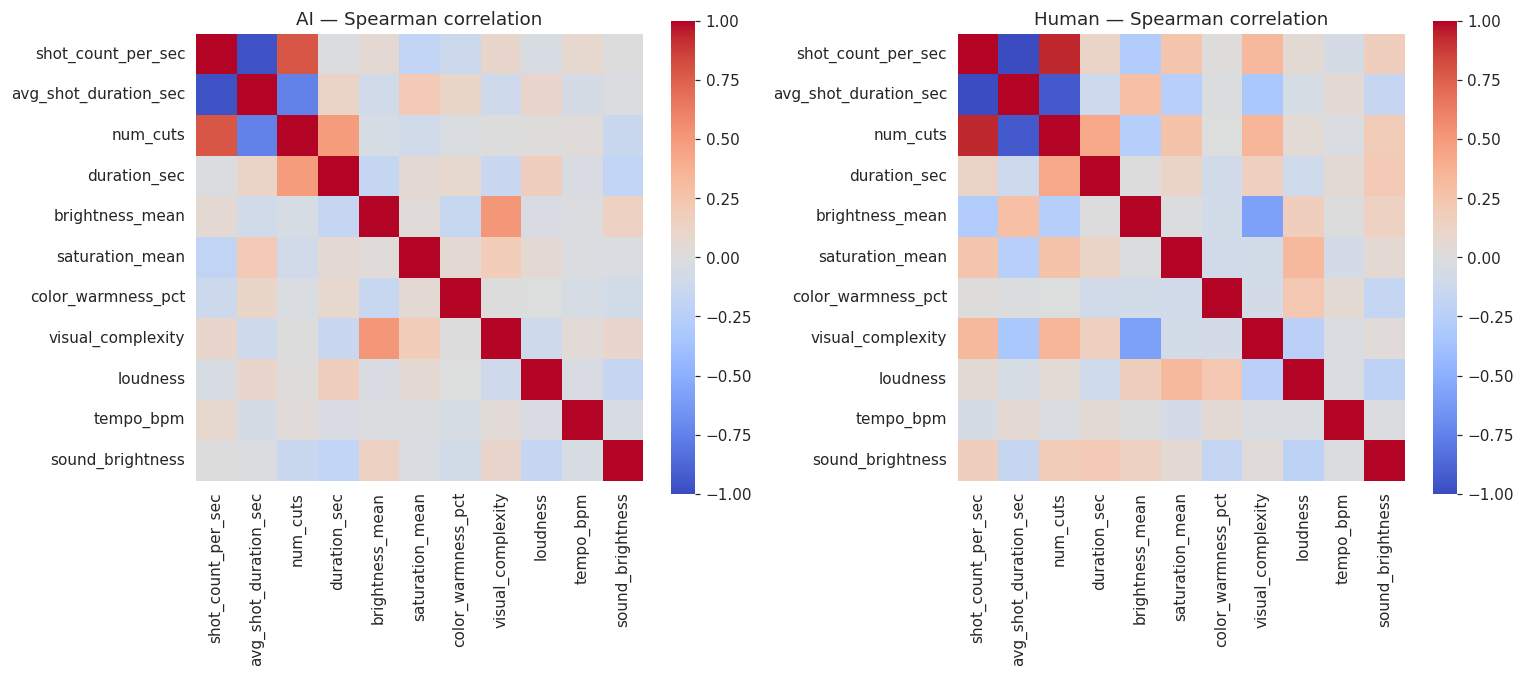

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, sub) in zip(axes, [('AI', ai_df), ('Human', human_df)]):
    corr = sub[FEATURES].corr(method='spearman')
    sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=False, cbar=True, square=True)
    ax.set_title(f'{name} — Spearman correlation')
plt.tight_layout()
plt.show()

## 7. Multiple-comparisons correction

With 11 features tested simultaneously, consider a Holm-Bonferroni or Benjamini-Hochberg (FDR)
correction rather than reading each p-value in isolation.

In [ ]:
from statsmodels.stats.multitest import multipletests

pvals = results_df['mwu_p'].values
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

results_df['mwu_p_fdr_corrected'] = pvals_corrected
results_df['significant_after_fdr'] = reject
results_df[['feature','mwu_p','mwu_p_fdr_corrected','significant_after_fdr']].sort_values('mwu_p')

,feature,mwu_p,mwu_p_fdr_corrected,significant_after_fdr
3,duration_sec,0.0000,0.000000,True
2,num_cuts,0.0000,0.000000,True
6,color_warmness_pct,0.0000,0.000000,True
4,brightness_mean,0.0000,0.000000,True
7,visual_complexity,0.0000,0.000000,True
10,sound_brightness,0.0000,0.000000,True
8,loudness,0.0047,0.007386,True
9,tempo_bpm,0.0422,0.058025,False
0,shot_count_per_sec,0.0819,0.100100,False
1,avg_shot_duration_sec,0.2440,0.268400,False


If a feature loses significance after FDR correction, treat that finding as more tentative
in the write-up — report it but flag it as not surviving multiple-comparisons correction.

## 8. Export results

Saves the full statistics table (including bootstrap CIs and FDR-corrected p-values) as a CSV
you can pull into a report or supplementary table.

In [ ]:
results_df.to_csv('extended_stats_results.csv', index=False)
print('Saved extended_stats_results.csv')
results_df

Saved extended_stats_results.csv


,feature,shapiro_ai_p,shapiro_human_p,both_normal,levene_p,equal_var,welch_p,cohens_d,mwu_p,rank_biserial,median_diff,median_diff_ci_lo,median_diff_ci_hi,recommended_test,mwu_p_fdr_corrected,significant_after_fdr
0,shot_count_per_sec,0.0000,0.0000,False,0.8978,True,0.2088,-0.1072,0.0819,0.0854,-0.0295,-0.0679,0.0083,Mann-Whitney U,0.100100,False
1,avg_shot_duration_sec,0.0000,0.0000,False,0.7139,True,0.8506,-0.0160,0.2440,-0.0572,0.8540,-0.4240,2.1216,Mann-Whitney U,0.268400,False
2,num_cuts,0.0000,0.0000,False,0.0010,False,0.0000,-0.4810,0.0000,0.2855,-7.0000,-10.0000,-5.0000,Mann-Whitney U,0.000000,True
3,duration_sec,0.0002,0.0000,False,0.0000,False,0.0000,-0.7780,0.0000,0.4325,-28.2135,-33.6537,-20.0010,Mann-Whitney U,0.000000,True
4,brightness_mean,0.0002,0.0000,False,0.0000,False,0.0000,-1.4592,0.0000,0.6788,-63.1995,-71.2851,-54.8977,Mann-Whitney U,0.000000,True
5,saturation_mean,0.0227,0.5699,False,0.0000,False,0.3317,-0.0835,0.3391,0.0470,-2.2550,-11.1710,4.5998,Mann-Whitney U,0.339100,False
6,color_warmness_pct,0.0554,0.0011,False,0.7079,True,0.0000,0.7817,0.0000,-0.4268,0.1634,0.1325,0.2078,Mann-Whitney U,0.000000,True
7,visual_complexity,0.0000,0.0000,False,0.0000,False,0.0000,1.3782,0.0000,-0.7998,1.2385,1.0540,1.5225,Mann-Whitney U,0.000000,True
8,loudness,0.0000,0.0000,False,0.8290,True,0.1947,-0.1099,0.0047,0.1395,-0.0139,-0.0272,-0.0034,Mann-Whitney U,0.007386,True
9,tempo_bpm,0.0000,0.0003,False,0.0646,True,0.0254,0.1907,0.0422,-0.1002,5.3200,0.0000,8.1600,Mann-Whitney U,0.058025,False
